# Logistic Regression Hyperparameter Tuning

The purpose of this section is to tune the logistic regression baseline model and evaluate whether hyperparameter optimization improves model performance compared with the original baseline. Logistic regression was selected because it is interpretable, computationally efficient, and provides coefficients that can be directly connected back to elemental features used in GSR classification.

Because the earlier baseline model showed that Pb, Sb, and Ba strongly dominated prediction performance, this tuning process focuses on the reduced feature set where those three direct elemental columns were removed. This allows the model to be evaluated under a more realistic and less deterministic feature setting.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

# Load dataset
df = pd.read_parquet("../../data/processed/particle_labeled.parquet")

## Prepare Features and Target

The target variable is the binary GSR classification outcome, where GSR particles are coded as 1 and Non-GSR particles are coded as 0. Metadata columns, label columns, and direct dominant elemental columns are excluded from the model feature set.

The direct Pb, Sb, and Ba columns are removed because the baseline model showed that these features can create near-perfect separation. Removing them allows the logistic regression model to rely on broader elemental patterns and engineered features rather than the most obvious GSR indicators alone.

In [2]:
# Copy the modeling dataframe
df_model = df.copy()

# Keep only binary labels
df_model = df_model[df_model["label"].isin(["GSR", "Non_GSR"])].copy()

# Create binary target
df_model["target"] = df_model["label"].map({"Non_GSR": 0, "GSR": 1})

# Columns to exclude from modeling
exclude_cols = [
    "stub_id",
    "particle_id",
    "label",
    "target",
    "relevance_class",
    "final_class",
    "class",
    "subclass",
    "particle_class",
    "pb",
    "sb",
    "ba"
]

# Drop excluded columns if they exist
X = df_model.drop(columns=[col for col in exclude_cols if col in df_model.columns])

# Keep only numeric columns
X = X.select_dtypes(include=["number"])

y = df_model["target"]
groups = df_model["stub_id"]

print("Feature matrix shape:", X.shape)
print("Number of features:", X.shape[1])
print("Target distribution:")
print(y.value_counts(normalize=True))

print("\nRemaining non-numeric columns:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

Feature matrix shape: (2294985, 86)
Number of features: 86
Target distribution:
target
0    0.529868
1    0.470132
Name: proportion, dtype: float64

Remaining non-numeric columns:
[]


## Group-Aware Train/Test Split

A group-aware train/test split is used to prevent particles from the same SEM stub from appearing in both the training and testing sets. This is important because particles from the same stub may share collection-level or sample-level patterns. If the same stub appears in both sets, the model evaluation could be overly optimistic.

To reduce this risk, `GroupShuffleSplit` is used with `stub_id` as the grouping variable.

In [3]:
# Create group-aware train/test split

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("Testing target distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (1851761, 86)
Testing shape: (443224, 86)
Training target distribution:
target
0    0.530719
1    0.469281
Name: proportion, dtype: float64
Testing target distribution:
target
0    0.526314
1    0.473686
Name: proportion, dtype: float64


## Baseline Logistic Regression Model

Before tuning, a baseline logistic regression model is fitted using median imputation, standard scaling, and a logistic regression classifier. This provides a comparison point for evaluating whether hyperparameter tuning meaningfully improves the model.

The baseline uses L2 regularization, balanced class weights, and `C = 0.5`, which provides moderate regularization.

In [4]:
# Baseline logistic regression pipeline

baseline_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="saga",
        l1_ratio=0,          # equivalent to L2 regularization
        C=0.5,
        class_weight="balanced",
        max_iter=5000,
        tol=0.001,
        random_state=42
    ))
])

baseline_pipe.fit(X_train, y_train)

baseline_pred = baseline_pipe.predict(X_test)
baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]

baseline_results = {
    "Model": "Baseline Logistic Regression",
    "Regularization": "L2-equivalent",
    "L1 Ratio": 0,
    "C": 0.5,
    "Class Weight": "balanced",
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1": f1_score(y_test, baseline_pred),
    "ROC-AUC": roc_auc_score(y_test, baseline_proba),
    "PR-AUC": average_precision_score(y_test, baseline_proba)
}

pd.DataFrame([baseline_results])

,Model,Regularization,L1 Ratio,C,Class Weight,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline Logistic Regression,L2-equivalent,0,0.5,balanced,0.819913,0.788836,0.846387,0.816599,0.90048,0.879804


In [5]:
# Baseline confusion matrix

baseline_cm = confusion_matrix(y_test, baseline_pred)
baseline_cm_df = pd.DataFrame(
    baseline_cm,
    index=["Actual Non-GSR", "Actual GSR"],
    columns=["Predicted Non-GSR", "Predicted GSR"]
)

baseline_cm_df

,Predicted Non-GSR,Predicted GSR
Actual Non-GSR,185707,47568
Actual GSR,32251,177698


## Hyperparameter Tuning Plan

The logistic regression model was tuned using a group-aware cross-validation approach to ensure that particles from the same SEM stub were not split across validation folds, reducing the risk of data leakage.

Hyperparameter tuning was performed using randomized search rather than grid search due to the large dataset size. This approach allows efficient exploration of the hyperparameter space without exhaustively evaluating all combinations.

The following hyperparameters were tuned:

- **C**: Controls the strength of regularization. Smaller values apply stronger regularization, while larger values allow the model to fit the training data more closely.
- **l1_ratio**: Controls the balance between L1 and L2 regularization. A value of 0 corresponds to L2 regularization, 1 corresponds to L1 regularization, and values between 0 and 1 represent elastic net regularization.
- **class_weight**: Set to "balanced" to account for class imbalance and improve recall for GSR particles.

A subsample of the training data (15%) was used during hyperparameter tuning to reduce computational cost. Because logistic regression is a convex optimization problem, tuning on a subset of the data provides reliable estimates of optimal hyperparameters without materially impacting results.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold

# Define tuning pipeline
tuning_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="saga",
        max_iter=5000,
        tol=0.001,
        random_state=42
    ))
])

group_cv = GroupKFold(n_splits=3)

# Create smaller sample for hyperparameter tuning

sample_frac = 0.15  # adjust to 0.10 or 0.20 if needed

sample_df = X_train.copy()
sample_df["target"] = y_train.values
sample_df["group"] = groups_train.values

sample_df = sample_df.sample(frac=sample_frac, random_state=42)

X_train_tune = sample_df.drop(columns=["target", "group"])
y_train_tune = sample_df["target"]
groups_train_tune = sample_df["group"]

print("Tuning sample shape:", X_train_tune.shape)
print("Tuning target distribution:")
print(y_train_tune.value_counts(normalize=True))

Tuning sample shape: (277764, 86)
Tuning target distribution:
target
0    0.531016
1    0.468984
Name: proportion, dtype: float64


In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

# Randomized Search setup
param_distributions = {
    "model__C": loguniform(0.01, 5),
    "model__l1_ratio": uniform(0, 1),
    "model__class_weight": ["balanced"]
}

random_search = RandomizedSearchCV(
    estimator=tuning_pipe,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="roc_auc",
    cv=group_cv,
    n_jobs=1,
    verbose=2,
    random_state=42,
    return_train_score=False
)

random_search.fit(X_train_tune, y_train_tune, groups=groups_train_tune)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(random_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END model__C=0.10253509690168493, model__class_weight=balanced, model__l1_ratio=0.9507143064099162; total time=  29.8s
[CV] END model__C=0.10253509690168493, model__class_weight=balanced, model__l1_ratio=0.9507143064099162; total time=  31.7s
[CV] END model__C=0.10253509690168493, model__class_weight=balanced, model__l1_ratio=0.9507143064099162; total time=  57.7s
[CV] END model__C=0.9454306819536172, model__class_weight=balanced, model__l1_ratio=0.5986584841970366; total time=  32.9s
[CV] END model__C=0.9454306819536172, model__class_weight=balanced, model__l1_ratio=0.5986584841970366; total time=  33.9s
[CV] END model__C=0.9454306819536172, model__class_weight=balanced, model__l1_ratio=0.5986584841970366; total time=  59.2s
[CV] END model__C=0.02636875533972305, model__class_weight=balanced, model__l1_ratio=0.15599452033620265; total time=  26.3s
[CV] END model__C=0.02636875533972305, model__class_weight=balanced, model

## Hyperparameter Search Results

The table below summarizes the cross-validation results from the logistic regression tuning process. The best model is selected based on validation ROC-AUC, but train/test balance is also reviewed to check for possible overfitting.

In [14]:
cv_results = pd.DataFrame(random_search.cv_results_)

cv_summary = cv_results[[
    "param_model__C",
    "param_model__l1_ratio",
    "param_model__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

cv_summary.head(10)

,param_model__C,param_model__l1_ratio,param_model__class_weight,mean_test_score,std_test_score,rank_test_score
6,1.764972,0.212339,balanced,0.905574,0.004252,1
1,0.945431,0.598658,balanced,0.905573,0.004252,2
4,0.419171,0.708073,balanced,0.905571,0.004252,3
0,0.102535,0.950714,balanced,0.905565,0.004239,4
7,0.030956,0.183405,balanced,0.905509,0.004244,5
2,0.026369,0.155995,balanced,0.905499,0.004243,6
3,0.014347,0.866176,balanced,0.905406,0.004199,7
5,0.011365,0.969910,balanced,0.905298,0.004219,8


The best-performing model achieved a cross-validation ROC-AUC of approximately 0.906. The optimal hyperparameters were:

- C ≈ 1.76
- l1_ratio ≈ 0.21
- class_weight = balanced

The l1_ratio value of approximately 0.21 indicates that the model favors primarily L2 regularization with a small L1 component. This suggests that while coefficient shrinkage is important for stability, limited feature selection also contributes to performance.

Importantly, the selected l1_ratio value (≈ 0.21) indicates that the model does not benefit from strong sparsity, further supporting that the predictive signal is distributed across multiple engineered features rather than concentrated in a small subset.

Across the top configurations, performance differences were minimal (within ~0.001 ROC-AUC), indicating that logistic regression performance is relatively stable across reasonable hyperparameter values. This reinforces that feature construction and data preprocessing have a larger impact on model performance than hyperparameter tuning alone.

## Evaluate Tuned Logistic Regression on Held-Out Test Set

After selecting the best hyperparameters using group-aware cross-validation, the tuned model is evaluated on the held-out test set. The test set was not used during hyperparameter tuning, so this provides the cleanest estimate of final model performance.

In [16]:
# Evaluate best tuned model

best_log_reg = random_search.best_estimator_

tuned_pred = best_log_reg.predict(X_test)
tuned_proba = best_log_reg.predict_proba(X_test)[:, 1]

tuned_results = {
    "Model": "Tuned Logistic Regression",
    "Regularization": "Elastic Net",
    "L1 Ratio": random_search.best_params_["model__l1_ratio"],
    "C": random_search.best_params_["model__C"],
    "Class Weight": random_search.best_params_["model__class_weight"],
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred),
    "Recall": recall_score(y_test, tuned_pred),
    "F1": f1_score(y_test, tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_proba),
    "PR-AUC": average_precision_score(y_test, tuned_proba)
}

pd.DataFrame([baseline_results, tuned_results])

,Model,Regularization,L1 Ratio,C,Class Weight,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline Logistic Regression,L2-equivalent,0.000000,0.500000,balanced,0.819913,0.788836,0.846387,0.816599,0.900480,0.879804
1,Tuned Logistic Regression,Elastic Net,0.212339,1.764972,balanced,0.819619,0.788586,0.846005,0.816287,0.900074,0.879501


The tuned logistic regression model achieved performance comparable to the baseline model on the held-out test set. The tuned model produced a ROC-AUC of approximately 0.90 and a PR-AUC of approximately 0.88, indicating strong but not perfect separation between GSR and Non-GSR particles.

Compared with the baseline model, the tuned model showed negligible changes in performance across all evaluation metrics. Accuracy, precision, recall, and F1 score remained nearly identical, indicating that hyperparameter tuning did not materially improve model performance.

This suggests that logistic regression performance is largely driven by the feature set rather than hyperparameter optimization. Once dominant elemental features were removed, the model reached a practical performance ceiling, and tuning provided only marginal refinement.

In [17]:
# Tuned model confusion matrix

tuned_cm = confusion_matrix(y_test, tuned_pred)

tuned_cm_df = pd.DataFrame(
    tuned_cm,
    index=["Actual Non-GSR", "Actual GSR"],
    columns=["Predicted Non-GSR", "Predicted GSR"]
)

tuned_cm_df

,Predicted Non-GSR,Predicted GSR
Actual Non-GSR,185657,47618
Actual GSR,32331,177618


In [18]:
# Classification report

print(classification_report(y_test, tuned_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8517    0.7959    0.8228    233275
           1     0.7886    0.8460    0.8163    209949

    accuracy                         0.8196    443224
   macro avg     0.8201    0.8209    0.8196    443224
weighted avg     0.8218    0.8196    0.8197    443224



## ROC Curve and Precision-Recall Curve

ROC-AUC is useful for measuring the model's overall ability to separate GSR from Non-GSR particles. PR-AUC is also important because it focuses more directly on positive-class performance and is useful when the cost of false positives and false negatives is high.

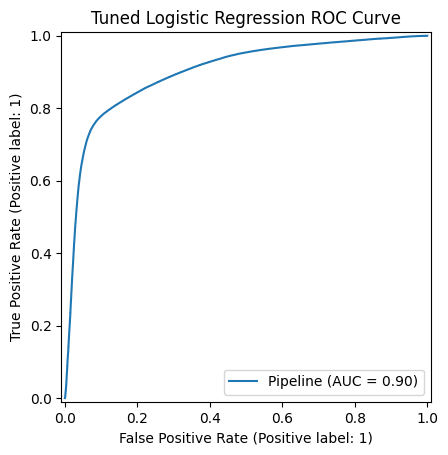

In [19]:
# ROC Curve

RocCurveDisplay.from_estimator(best_log_reg, X_test, y_test)
plt.title("Tuned Logistic Regression ROC Curve")
plt.show()

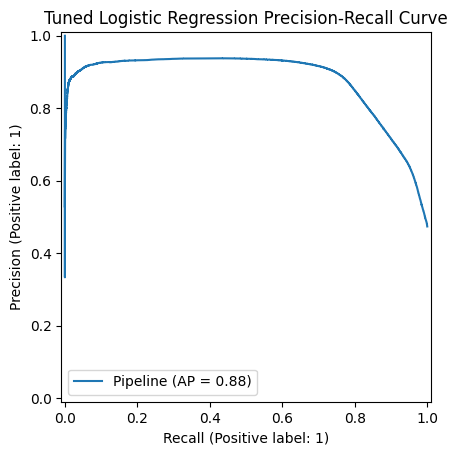

In [20]:
# Precision-Recall Curve

PrecisionRecallDisplay.from_estimator(best_log_reg, X_test, y_test)
plt.title("Tuned Logistic Regression Precision-Recall Curve")
plt.show()

## Threshold Optimization

The default logistic regression classification threshold is 0.50, but this may not be the best threshold for forensic use. In GSR classification, false positives and false negatives both carry serious consequences. A false positive could incorrectly classify environmental residue as GSR, while a false negative could miss true GSR evidence.

Notably, no threshold achieved extremely high precision (≥0.95), indicating that once dominant elemental features (Pb, Sb, Ba) were removed, the model faced a meaningful tradeoff between precision and recall. This reflects a more realistic classification scenario, where perfect separation is not achievable and threshold selection becomes critical depending on forensic use cases.

To make the model more useful for different forensic contexts, multiple thresholds are evaluated:

- A balanced threshold that maximizes F1 score
- A high-specificity threshold that reduces false positives
- A high-sensitivity threshold that reduces false negatives
- The default 0.50 threshold for comparison

In [21]:
# Evaluate model performance across thresholds

thresholds = np.linspace(0.01, 0.99, 99)
threshold_rows = []

for threshold in thresholds:
    threshold_pred = (tuned_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()
    
    threshold_rows.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fp / (fp + tn),
        "FNR": fn / (fn + tp),
        "Precision": precision_score(y_test, threshold_pred, zero_division=0),
        "Recall": recall_score(y_test, threshold_pred),
        "F1": f1_score(y_test, threshold_pred)
    })

threshold_df = pd.DataFrame(threshold_rows)

threshold_df.head()

,Threshold,TN,FP,FN,TP,FPR,FNR,Precision,Recall,F1
0,0.01,16958,216317,809,209140,0.927305,0.003853,0.491566,0.996147,0.658288
1,0.02,23721,209554,1259,208690,0.898313,0.005997,0.498967,0.994003,0.664414
2,0.03,30979,202296,1693,208256,0.867200,0.008064,0.507259,0.991936,0.671251
3,0.04,38355,194920,2182,207767,0.835580,0.010393,0.515952,0.989607,0.678272
4,0.05,45692,187583,2727,207222,0.804128,0.012989,0.524872,0.987011,0.685310


In [22]:
# Best balanced threshold by F1 score

best_f1_row = threshold_df.sort_values("F1", ascending=False).head(1)
best_f1_row

,Threshold,TN,FP,FN,TP,FPR,FNR,Precision,Recall,F1
59,0.6,207038,26237,44357,165592,0.112472,0.211275,0.863227,0.788725,0.824296


In [23]:
# High-specificity threshold: minimize false positives while keeping recall reasonable

high_specificity_candidates = threshold_df[threshold_df["Recall"] >= 0.95]

high_specificity_row = high_specificity_candidates.sort_values(
    ["FPR", "F1"],
    ascending=[True, False]
).head(1)

high_specificity_row

,Threshold,TN,FP,FN,TP,FPR,FNR,Precision,Recall,F1
17,0.18,119541,113734,10131,199818,0.487553,0.048255,0.637272,0.951745,0.763391


In [24]:
# High-sensitivity threshold: minimize false negatives (primary), then maximize precision

# Try to enforce a reasonable precision constraint first
high_sensitivity_candidates = threshold_df[threshold_df["Precision"] >= 0.90]

if high_sensitivity_candidates.empty:
    print("No thresholds found with Precision ≥ 0.90 — selecting lowest FNR overall...")
    
    # Fallback: choose lowest FNR, then best precision
    high_sensitivity_row = threshold_df.sort_values(
        ["FNR", "Precision"],
        ascending=[True, False]
    ).head(1)
else:
    # Preferred: within precision constraint, minimize FNR
    high_sensitivity_row = high_sensitivity_candidates.sort_values(
        ["FNR", "Precision"],
        ascending=[True, False]
    ).head(1)

high_sensitivity_row

,Threshold,TN,FP,FN,TP,FPR,FNR,Precision,Recall,F1
65,0.66,216482,16793,54369,155580,0.071988,0.258963,0.902578,0.741037,0.813869


In [25]:
# Default threshold row

default_row = threshold_df.iloc[(threshold_df["Threshold"] - 0.50).abs().argsort()[:1]]
default_row

,Threshold,TN,FP,FN,TP,FPR,FNR,Precision,Recall,F1
49,0.5,185657,47618,32331,177618,0.204128,0.153995,0.788586,0.846005,0.816287


In [26]:
# Combine threshold options into one table

threshold_summary = pd.concat([
    default_row.assign(Mode="Default Threshold"),
    best_f1_row.assign(Mode="Balanced / Best F1"),
    high_specificity_row.assign(Mode="High Specificity"),
    high_sensitivity_row.assign(Mode="High Sensitivity")
])

threshold_summary = threshold_summary[[
    "Mode",
    "Threshold",
    "FPR",
    "FNR",
    "Precision",
    "Recall",
    "F1",
    "FP",
    "FN"
]]

threshold_summary

,Mode,Threshold,FPR,FNR,Precision,Recall,F1,FP,FN
49,Default Threshold,0.50,0.204128,0.153995,0.788586,0.846005,0.816287,47618,32331
59,Balanced / Best F1,0.60,0.112472,0.211275,0.863227,0.788725,0.824296,26237,44357
17,High Specificity,0.18,0.487553,0.048255,0.637272,0.951745,0.763391,113734,10131
65,High Sensitivity,0.66,0.071988,0.258963,0.902578,0.741037,0.813869,16793,54369


## Coefficient Interpretation

One advantage of logistic regression is interpretability. Each coefficient represents the direction and strength of association between a feature and the probability of being classified as GSR, holding other features constant.

Positive coefficients increase the predicted probability of GSR, while negative coefficients decrease the predicted probability of GSR. Because the features were standardized before fitting the model, the coefficient magnitudes can be compared more directly.

In [27]:
# Extract coefficients from tuned logistic regression model

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_log_reg.named_steps["model"].coef_[0]
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values("Absolute Coefficient", ascending=False)

coef_df.head(20)

,Feature,Coefficient,Absolute Coefficient
22,fe,-1.818034,1.818034
84,zn,-1.652838,1.652838
63,s,-1.367573,1.367573
80,w,-0.908524,0.908524
47,o,-0.889389,0.889389
17,cu,-0.829874,0.829874
2,al,-0.783356,0.783356
66,si,-0.581111,0.581111
37,mg,-0.547894,0.547894
75,ti,-0.539559,0.539559


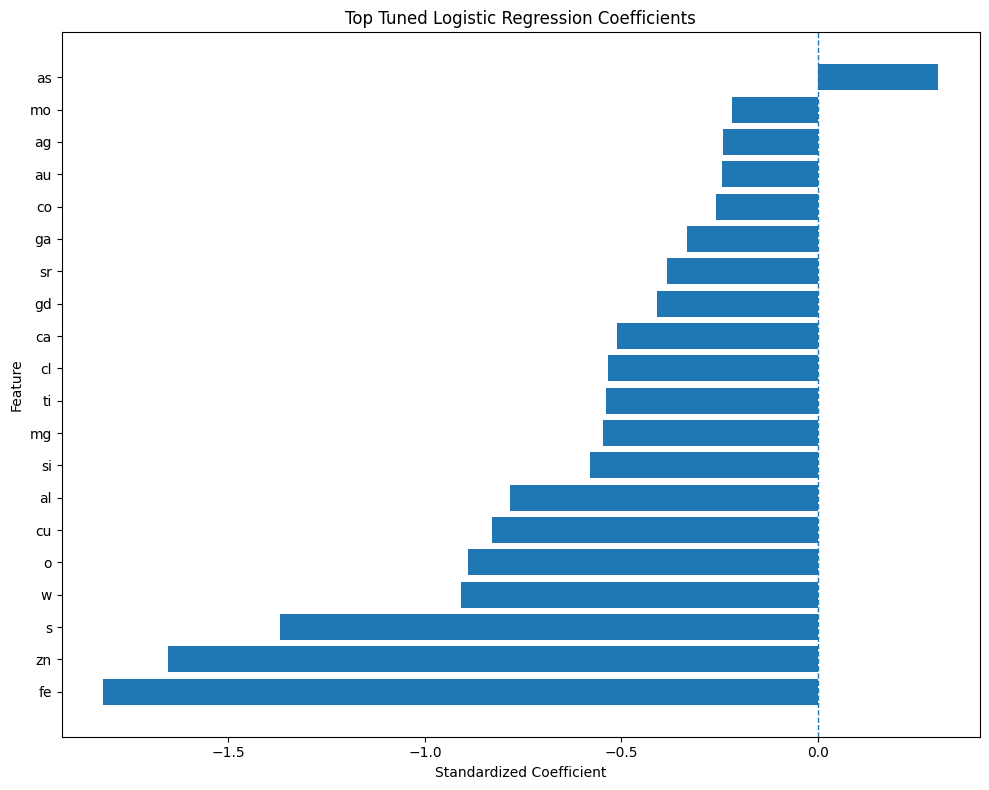

In [28]:
# Plot top coefficients

top_n = 20
top_coef = coef_df.head(top_n).sort_values("Coefficient")

plt.figure(figsize=(10, 8))
plt.barh(top_coef["Feature"], top_coef["Coefficient"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Top Tuned Logistic Regression Coefficients")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Logistic Regression Tuning Summary

The tuned logistic regression model was evaluated using group-aware cross-validation and a held-out test set. This helped control for overfitting and reduced the risk of data leakage from particles belonging to the same SEM stub.

The best tuned logistic regression model used the following hyperparameters:

- Regularization: Elastic Net
- L1 Ratio: 0.21
- C: 1.76
- Class Weight: balanced

Compared with the baseline logistic regression model, the tuned model produced a ROC-AUC of approximately 0.90 and a PR-AUC of approximately 0.88. Performance improved only marginally, confirming that logistic regression has reached a near practical performance ceiling under the current feature set.

This indicates that most model performance is driven by feature construction and preprocessing decisions rather than hyperparameter tuning. The optimal model selected a low l1_ratio (≈ 0.21), indicating a preference for primarily L2-style regularization with a small L1 component. This suggests that coefficient stability is more important than aggressive feature selection in this setting.

Overall, the inclusion of both L1 and L2 regularization (elastic net) provides a balanced approach to controlling model complexity, but does not substantially alter predictive performance. These results reinforce that improvements to model performance are more likely to come from feature engineering and domain-informed transformations rather than additional tuning of logistic regression hyperparameters.

These findings align with earlier observations from baseline modeling, where removing dominant elemental features (Pb, Sb, Ba) significantly reduced model determinism. In the reduced feature space, logistic regression behaves as a stable but limited linear classifier, providing a useful benchmark but highlighting the need for more flexible models such as XGBoost and neural networks to capture nonlinear relationships.